# Phase 2 — Dataset Acquisition and Data Understanding
## Real-Time Fraud Detection System

This notebook focuses solely on acquiring, inspecting, and understanding the raw **Credit Card Fraud Detection** dataset.

**Phase 2 Guidelines**:
- No ML model training
- No SMOTE or synthetic sampling
- No feature scaling or encoding
- No row deletion or train/test splitting
- Strictly understanding raw data distributions, schema, missing values, duplicates, and class imbalance.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Visual formatting configurations
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
sns.set_theme(style='whitegrid')


## 1. Load the Raw Dataset
The dataset is loaded directly from `../data/raw/creditcard.csv` without modifying or transforming the underlying raw file.


In [2]:
data_path = '../data/raw/creditcard.csv'
df = pd.read_csv(data_path)
print(f'Successfully loaded raw dataset from: {data_path}')


Successfully loaded raw dataset from: ../data/raw/creditcard.csv


## 2. Dataset Dimensions and Overview
Checking row and column dimensions, column list, and data types.


In [3]:
print(f'Total Number of Rows:    {df.shape[0]:,}')
print(f'Total Number of Columns: {df.shape[1]}')
print('\nColumn Names:')
print(list(df.columns))
print('\nData Types Summary:')
print(df.dtypes.value_counts())


Total Number of Rows:    284,807
Total Number of Columns: 31

Column Names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data Types Summary:
float64    30
int64       1
Name: count, dtype: int64


### First 5 Rows (`df.head()`)


In [4]:
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Last 5 Rows (`df.tail()`)


In [5]:
df.tail()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,4.356170,-1.593105,2.711941,-0.689256,4.626942,-0.924459,1.107641,1.991691,0.510632,-0.682920,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,-0.975926,-0.150189,0.915802,1.214756,-0.675143,1.164931,-0.711757,-0.025693,-1.221179,-1.545556,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,-0.484782,0.411614,0.063119,-0.183699,-0.510602,1.329284,0.140716,0.313502,0.395652,-0.577252,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,-0.399126,-1.933849,-0.962886,-1.042082,0.449624,1.962563,-0.608577,0.509928,1.113981,2.897849,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,-0.915427,-1.040458,-0.031513,-0.188093,-0.084316,0.041333,-0.302620,-0.660377,0.167430,-0.256117,0.382948,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


### Column Data Types & Non-Null Counts (`df.info()`)


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 ...
 28  V28     284807 non-null  float64
 29  Amount  284807 non-null  float64
 30  Class   284807 non-null  int64  
dtypes: float64(30), int64(1)
memory usage: 67.4 MB


## 3. Data Integrity: Missing Values & Duplicate Rows
Auditing missing/null values across all columns and inspecting duplicate rows.


In [7]:
missing_counts = df.isnull().sum()
total_missing = missing_counts.sum()
duplicate_count = df.duplicated().sum()

print(f'Total Missing Values across entire dataset: {total_missing}')
print(f'Number of Duplicate Rows: {duplicate_count:,} ({duplicate_count / len(df) * 100:.2f}%)')
print('\nUnique values for primary tracking features:')
print(f' - Time:   {df["Time"].nunique():,} unique values')
print(f' - Amount: {df["Amount"].nunique():,} unique values')
print(f' - Class:  {df["Class"].unique().tolist()}')


Total Missing Values across entire dataset: 0
Number of Duplicate Rows: 1,081 (0.38%)

Unique values for primary tracking features:
 - Time:   124,592 unique values
 - Amount: 32,767 unique values
 - Class:  [0, 1]


## 4. Target Column Identification and Class Imbalance Analysis
The target column for classification is **`Class`**:
- **0**: Legitimate Transaction
- **1**: Fraudulent Transaction


In [8]:
target_col = 'Class'
class_counts = df[target_col].value_counts()
class_pcts = df[target_col].value_counts(normalize=True) * 100

legit_count = class_counts[0]
fraud_count = class_counts[1]
imbalance_ratio = legit_count / fraud_count

print('=' * 56)
print('          TARGET VARIABLE DISTRIBUTION')
print('=' * 56)
print(f'Legitimate Transactions (Class 0): {legit_count:>10,} ({class_pcts[0]:>7.4f}%)')
print(f'Fraudulent Transactions (Class 1): {fraud_count:>10,} ({class_pcts[1]:>7.4f}%)')
print('-' * 56)
print(f'Total Transactions:                {len(df):>10,}')
print(f'Class Imbalance Ratio:             1 fraud per {imbalance_ratio:.1f} legitimate transactions')
print(f'Fraud Incidence Rate:              {class_pcts[1]:.4f}%')
print('=' * 56)


          TARGET VARIABLE DISTRIBUTION
Legitimate Transactions (Class 0):    284,315 (99.8273%)
Fraudulent Transactions (Class 1):        492 ( 0.1727%)
--------------------------------------------------------
Total Transactions:                   284,807
Class Imbalance Ratio:             1 fraud per 577.9 legitimate transactions
Fraud Incidence Rate:              0.1727%


## 5. Descriptive Statistics
Summary statistics across key non-PCA numerical variables and PCA components.


In [9]:
# Summary statistics for non-PCA columns
print('--- Descriptive Statistics for Time and Amount ---')
display(df[['Time', 'Amount']].describe())

# Distribution of Amount split by Class
print('\n--- Amount Statistics by Class ---')
print('Legitimate (Class 0):')
print(df[df['Class'] == 0]['Amount'].describe())
print('\nFraudulent (Class 1):')
print(df[df['Class'] == 1]['Amount'].describe())


--- Descriptive Statistics for Time and Amount ---


,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000



--- Amount Statistics by Class ---
Legitimate (Class 0):
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000

Fraudulent (Class 1):
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000


## 6. Categorical vs. Numerical Feature Identification


In [10]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

print(f'Total Numerical Columns:   {len(numerical_cols)}')
print(f'Total Categorical Columns: {len(categorical_cols)}')
print(f'Numerical column list: {numerical_cols}')
print(f'Categorical column list: {categorical_cols}')


Total Numerical Columns:   31
Total Categorical Columns: 0
Numerical column list: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Categorical column list: []


## 7. Initial Visualizations
### 7.1 Fraud vs. Legitimate Transaction Count


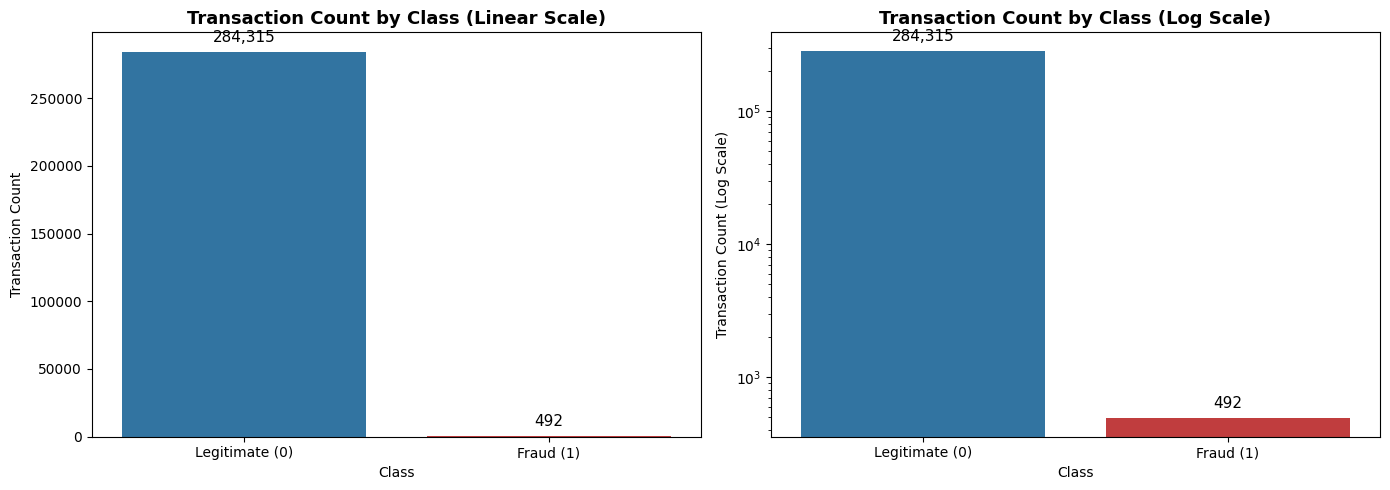

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
sns.countplot(data=df, x='Class', ax=axes[0], palette=['#1f77b4', '#d62728'], hue='Class', legend=False)
axes[0].set_title('Transaction Count by Class (Linear Scale)', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[0].set_ylabel('Transaction Count')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

# Log scale
sns.countplot(data=df, x='Class', ax=axes[1], palette=['#1f77b4', '#d62728'], hue='Class', legend=False)
axes[1].set_yscale('log')
axes[1].set_title('Transaction Count by Class (Log Scale)', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Legitimate (0)', 'Fraud (1)'])
axes[1].set_ylabel('Transaction Count (Log Scale)')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                      ha='center', va='bottom', fontsize=11, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()


### 7.2 Transaction Amount Distribution by Class


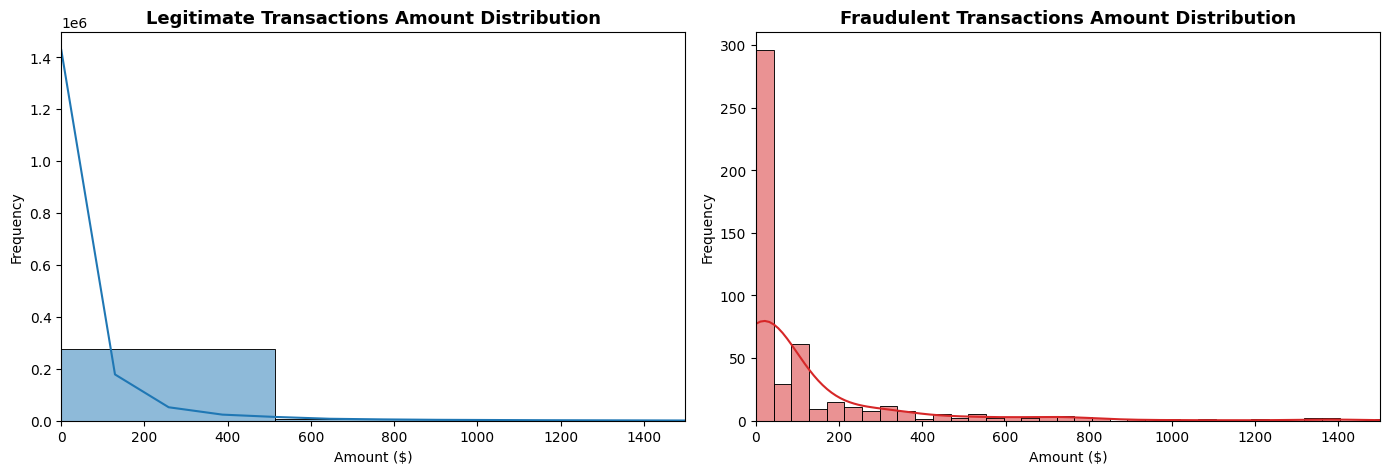

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution - Legitimate
sns.histplot(df[df['Class'] == 0]['Amount'], bins=50, ax=axes[0], color='#1f77b4', kde=True)
axes[0].set_title('Legitimate Transactions Amount Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(0, 1500)

# Amount distribution - Fraudulent
sns.histplot(df[df['Class'] == 1]['Amount'], bins=50, ax=axes[1], color='#d62728', kde=True)
axes[1].set_title('Fraudulent Transactions Amount Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Amount ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(0, 1500)

plt.tight_layout()
plt.show()


## 8. Summary of Data Understanding Findings
1. **Total Records**: 284,807 transactions with 31 columns.
2. **Missing Values**: None (0 missing values across all columns).
3. **Class Disparity**: Severe class imbalance.
   - Legitimate (0): 284,315 (99.8273%)
   - Fraudulent (1): 492 (0.1727%)
   - Ratio: ~578 legitimate transactions per 1 fraudulent transaction.
4. **Duplicate Records**: 1,081 duplicate rows identified. As required by Phase 2 rules, no rows have been deleted or modified.
5. **Feature Representation**: 
   - `Time`: Elapsed seconds since first recorded transaction.
   - `V1` - `V28`: PCA-transformed numerical features protecting user privacy.
   - `Amount`: Transaction monetary value, positively skewed (mean $88.35, median $22.00, max $25,691.16).
   - `Class`: Binary indicator (0 or 1).
6. **Next Steps (Phase 3)**: Establish proper stratified/temporal cross-validation and feature scaling before any modeling.
